# Week 3 Homework 

## Purpose of Homework

This homework assignment will help you practice building and evaluating a linear regression model for prediction. You will predict movie popularity using features that are different from those used in lecture and lab.

You are encouraged to refer to lecture content and liberally use course resources such as the discussion board and office hours.

## Logistics

Due date: The homework is due 12:00pm on Thursday, January 29, 2026.

You will submit your homework on [MarkUs](https://markus.teach.cs.toronto.edu/markus/). 

1. Download this file (`STA272_hw3_student.ipynb`) from JupyterHub. (See [our JupyterHub Guide](../guides/jupyterhub_guide.ipynb) for detailed instructions.)
2. Submit this file to MarkUs under the hw3 assignment. (See [our MarkUs Guide](../guides/markus_guide.ipynb) for detailed instructions.)

All homeworks will take place in a Jupyter notebook (like this one). When you are done, you will download this notebook and submit it to MarkUs.

## Predicting Movie Popularity

In lecture and lab, we predicted movie revenue using features like budget, popularity, and genre indicators. In this homework, you will flip the problem around and **predict popularity** using different features.

Complete the following tasks and answer the questions.

## Task #1

Read `movies_modeling.csv` into a pandas dataframe called `movies_df`.

In [91]:
# Import necessary libraries
import pandas as pd
import numpy as np
import re

# Read the CSV file into a dataframe
movies_df = pd.read_csv('movies_modeling.csv')

# Display the first few rows
movies_df.head()

,movie_id,title,revenue,popularity,budget,release_date,runtime,genres,vote_average,production_companies,production_countries,actors,crews,actor_avg_pop,crew_avg_pop,cast_count,crew_count
0,19995,Avatar,2923706026,54.7630,237000000,2009-12-16,162,"Action,Adventure,Fantasy,Science Fiction",7.600,"Dune Entertainment,Lightstorm Entertainment,20...","US,GB","Sam Worthington(6.2), Zoe Saldaña(9.9), Sigour...","John Refoua(0.2), Stephen E. Rivkin(0.2), Terr...",5.91624,1.0789,67,991
1,299534,Avengers: Endgame,2799439100,17.8597,356000000,2019-04-24,181,"Adventure,Science Fiction,Action",8.237,Marvel Studios,US,"Robert Downey Jr.(8.7), Chris Evans(7.2), Mark...","Paul Schneider(0.3), Louis D'Esposito(1.2), Ca...",8.80360,0.4552,107,608
2,76600,Avatar: The Way of Water,2353096253,61.9541,350000000,2022-12-14,192,"Action,Adventure,Science Fiction",7.602,"20th Century Studios,Lightstorm Entertainment,...",US,"Sam Worthington(6.2), Zoe Saldaña(9.9), Sigour...","James Cameron(4.1), James Cameron(4.1), James ...",6.40434,2.5273,57,205
3,597,Titanic,2264162353,27.6669,200000000,1997-12-18,194,"Drama,Romance",7.900,"Paramount Pictures,20th Century Fox,Lightstorm...",US,"Leonardo DiCaprio(9.4), Kate Winslet(6.5), Bil...","James Cameron(4.1), James Horner(0.7), Russell...",4.99382,1.9788,116,262
4,980477,Ne Zha 2,2259822417,42.1851,80000000,2025-01-29,144,"Animation,Fantasy,Adventure,Action",8.123,"Chengdu Coco Cartoon,Beijing Enlight Pictures,...",CN,"Lu Yanting(1.1), Joseph(0.6), Han Mo(1.0), Che...","Jiao Zi(0.6), Jiao Zi(0.6), Liu Wenzhang(0.3),...",0.78002,0.4221,24,10


## Task #1b

Make a histogram of the variable `popularity`

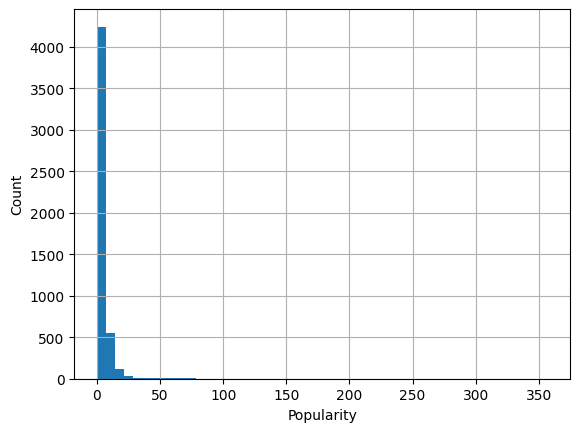

In [101]:
import matplotlib.pyplot as plt

plt.figure()
movies_df["popularity"].hist(bins=50)
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()

## Task #2

Create a binary indicator variable called `popular_genres` that equals 1 if a movie has at least one of the following genres: `Action`, `Adventure`, `Comedy`, or `Drama`, and 0 otherwise.

In [92]:
# Create popular_genres indicator
popular_genre_list = ['Action', 'Adventure', 'Comedy', 'Drama']
movies_df['popular_genres'] = movies_df['genres'].fillna('').apply(
    lambda x: int(any(genre in x for genre in popular_genre_list))
)

# Check your work
movies_df[['title', 'genres', 'popular_genres']].head(10)

,title,genres,popular_genres
0,Avatar,"Action,Adventure,Fantasy,Science Fiction",1
1,Avengers: Endgame,"Adventure,Science Fiction,Action",1
2,Avatar: The Way of Water,"Action,Adventure,Science Fiction",1
3,Titanic,"Drama,Romance",1
4,Ne Zha 2,"Animation,Fantasy,Adventure,Action",1
5,Star Wars: The Force Awakens,"Adventure,Action,Science Fiction",1
6,Avengers: Infinity War,"Adventure,Action,Science Fiction",1
7,Spider-Man: No Way Home,"Action,Adventure,Science Fiction",1
8,Zootopia 2,"Animation,Comedy,Adventure,Family,Mystery",1
9,Inside Out 2,"Animation,Adventure,Comedy,Family",1


## Task #3

The `release_date` column contains dates in the format `YYYY-MM-DD` (e.g., `2023-12-16`).

Using `release_date` create the following features:

1. `release_month` - extract the month (1-12) from the `release_date` column
2. `release_year` - extract the year from the `release_date` column
3. `summer_release` - a binary indicator (1 or 0) for whether the movie was released in summer (June, July, or August, i.e., months 6, 7, or 8)


**Hints:** 
- Use `pd.to_datetime()` to convert the date string, then use `.dt.month` and `.dt.year` to extract components


In [93]:
# Convert release_date to datetime and extract month
movies_df['release_month'] = pd.to_datetime(movies_df['release_date']).dt.month

# Create release_year 
movies_df['release_year'] = pd.to_datetime(movies_df['release_date']).dt.year

# Create summer_release indicator (months 6, 7, 8)
movies_df['summer_release'] = movies_df['release_month'].isin([6, 7, 8]).astype(int)

# Check your work
movies_df[['title', 'release_date', 'release_month', 'release_year', 'summer_release']].head(10)

,title,release_date,release_month,release_year,summer_release
0,Avatar,2009-12-16,12,2009,0
1,Avengers: Endgame,2019-04-24,4,2019,0
2,Avatar: The Way of Water,2022-12-14,12,2022,0
3,Titanic,1997-12-18,12,1997,0
4,Ne Zha 2,2025-01-29,1,2025,0
5,Star Wars: The Force Awakens,2015-12-15,12,2015,0
6,Avengers: Infinity War,2018-04-25,4,2018,0
7,Spider-Man: No Way Home,2021-12-15,12,2021,0
8,Zootopia 2,2025-11-26,11,2025,0
9,Inside Out 2,2024-06-11,6,2024,1


## Task #4 

The `actors` column lists actor names followed by popularity scores in parentheses (e.g., `Sam Worthington(6.2), Zoe Saldaña(9.9)`). 

Use `re.findall()` with the pattern `r'\((\d+\.?\d*)\)'` to extract popularity scores from each row. Then create a new variable, `actor_max_pop`, equal to the **maximum** popularity score found in that row's `actors` string.


In [94]:
def extract_max_popularity(actors_string):
    """Extract the maximum popularity score from the actors string."""
    if pd.isna(actors_string):
        return np.nan
    # Use regex to find all numbers in parentheses
    scores = re.findall(r'\((\d+\.?\d*)\)', actors_string)
    if scores:
        return max([float(s) for s in scores])
    return np.nan

# Apply the function to create actor_max_pop
movies_df['actor_max_pop'] = movies_df['actors'].apply(extract_max_popularity)

# Check your work
movies_df[['title', 'actors', 'actor_max_pop']].head()

,title,actors,actor_max_pop
0,Avatar,"Sam Worthington(6.2), Zoe Saldaña(9.9), Sigour...",9.9
1,Avengers: Endgame,"Robert Downey Jr.(8.7), Chris Evans(7.2), Mark...",18.2
2,Avatar: The Way of Water,"Sam Worthington(6.2), Zoe Saldaña(9.9), Sigour...",9.9
3,Titanic,"Leonardo DiCaprio(9.4), Kate Winslet(6.5), Bil...",9.4
4,Ne Zha 2,"Lu Yanting(1.1), Joseph(0.6), Han Mo(1.0), Che...",1.1


## Task #5

For our model, we will use `popularity` as the response (y) and the following as predictors (X):
- `revenue`
- `vote_average`
- `runtime`
- `release_month`
- `release_year`
- `summer_release`
- `actor_max_pop`
- `cast_count`
- `crew_count`
- `popular_genres`

Check the number of missing values in these key variables. Then remove any rows with missing values in these variables and store the result in `movies_df_clean`.

In [95]:
# Define key variables
key_vars = ['popularity', 'revenue', 'cast_count', 'crew_count', 'release_month', 'release_year',
            'vote_average', 'runtime', 'summer_release', 'actor_max_pop', 'popular_genres']

# Check missing values
print("Missing values in key variables:")
print(movies_df[key_vars].isnull().sum())

# Remove rows with missing values
movies_df_clean = movies_df.dropna(subset=key_vars)

print(f"\nOriginal dataset size: {len(movies_df)}")
print(f"Clean dataset size: {len(movies_df_clean)}")

Missing values in key variables:
popularity        0
revenue           0
cast_count        0
crew_count        0
release_month     0
release_year      0
vote_average      0
runtime           0
summer_release    0
actor_max_pop     5
popular_genres    0
dtype: int64

Original dataset size: 5000
Clean dataset size: 4995


## Task #6

Using `sklearn.model_selection.KFold`, set up **10-fold cross validation**. Set your **seed** by specifying `random_state = 123` and use `shuffle = True`.

In [96]:
from sklearn.model_selection import KFold


# Define X and y
X = movies_df_clean[['revenue', 'vote_average', 'runtime', 'release_month', 'release_year', 
                      'summer_release', 'actor_max_pop', 'cast_count', 'crew_count', 'popular_genres']]
y = movies_df_clean['popularity']

# Set up 10-fold cross validation
kf = KFold(n_splits=10, shuffle=True, random_state=123)

print(f"Number of folds: {kf.get_n_splits()}")
print(f"Total samples: {len(X)}")

Number of folds: 10
Total samples: 4995


## Task #7

Fit a linear regression model using `statsmodels` and perform 10-fold cross validation. For each fold, fit the model on the training data and calculate the $R^2$ on the test data. 

Report the $R^2$ and RMSE for each fold and the mean cross-validated $R^2$ and RMSE.

**Hint:** Remember to add a constant term using `sm.add_constant()`.

In [100]:
import statsmodels.api as sm
from sklearn.metrics import r2_score, root_mean_squared_error

# Store results for each fold
cv_r2_scores = []
cv_rmse_scores = []
y_pred_all = np.full(len(y), np.nan)  # Store predictions for all observations

# Perform 10-fold cross validation
for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Add constant
    X_train_const = sm.add_constant(X_train)
    X_test_const = sm.add_constant(X_test)
    
    # Fit model
    model = sm.OLS(y_train, X_train_const).fit()
    
    # Predict on test set
    y_pred = model.predict(X_test_const)
    
    # Store predictions
    y_pred_all[test_idx] = y_pred
    
    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    
    cv_r2_scores.append(r2)
    cv_rmse_scores.append(rmse)
    
    print(f"Fold {fold}: R² = {r2:.4f}, RMSE = {rmse:.4f}")

print(f"\nMean CV R²: {np.mean(cv_r2_scores):.4f}")
print(f"\nMean CV RMSE: {np.mean(cv_rmse_scores):.4f}")


Fold 1: R² = 0.1470, RMSE = 6.4109
Fold 2: R² = 0.2493, RMSE = 6.1517
Fold 3: R² = 0.1445, RMSE = 6.2558
Fold 4: R² = 0.0514, RMSE = 16.1422
Fold 5: R² = 0.2096, RMSE = 4.1860
Fold 6: R² = 0.2174, RMSE = 6.3456
Fold 7: R² = 0.2160, RMSE = 4.7414
Fold 8: R² = 0.1509, RMSE = 10.0148
Fold 9: R² = 0.1475, RMSE = 12.3824
Fold 10: R² = 0.1019, RMSE = 10.5940

Mean CV R²: 0.1636

Mean CV RMSE: 8.3225


## Task #8

Using the stored predictions from cross-validation, create a scatter plot of actual vs predicted popularity values.

Label the x-axis as "Actual Popularity", the y-axis as "Predicted Popularity", and the title as "Actual vs Predicted Popularity (10-Fold CV)".

**Store the resulting matplotlib figure in a variable called `pred_plot_fig`.**

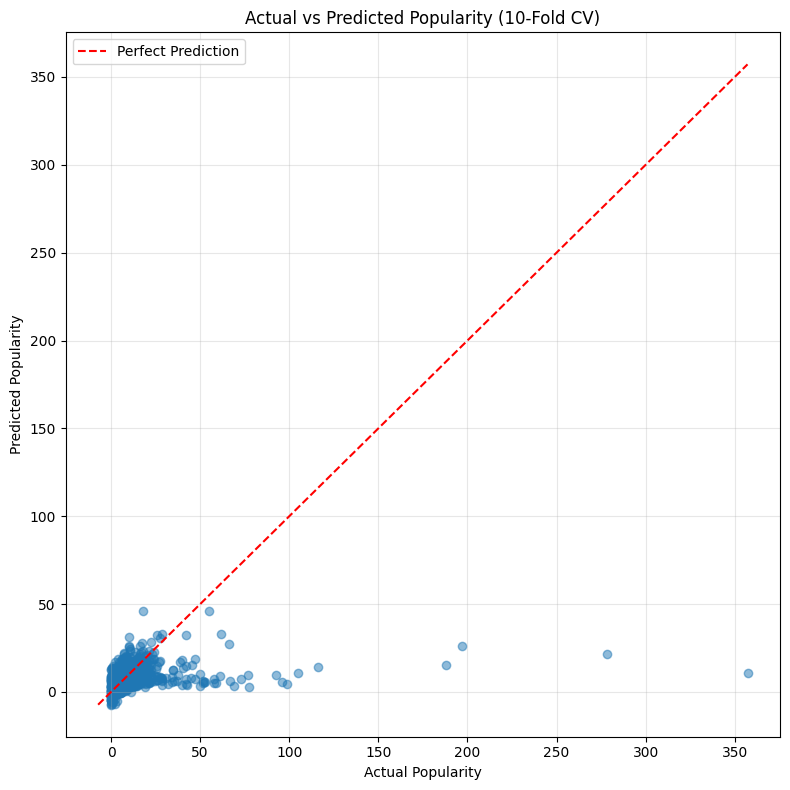

<Figure size 640x480 with 0 Axes>

In [98]:
import matplotlib.pyplot as plt

# Create the scatter plot
plt.figure(figsize=(8, 8))

# Plot actual vs predicted
plt.scatter(y, y_pred_all, alpha=0.5)

# Add 45-degree reference line
min_val = min(y.min(), y_pred_all.min())
max_val = max(y.max(), y_pred_all.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

# Add labels and title
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('Actual vs Predicted Popularity (10-Fold CV)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Store the figure
pred_plot_fig = plt.gcf()


## Question #1

Based on the cross-validated $R^2$ and RMSE from Tasks #6 and #7, how well does the linear regression model predict movie popularity? What do these metrics tell you about the model's performance?

**To obtain full marks (4 points):**
- Correctly state the mean cross-validated $R^2$ and RMSE values (1 point)
- Explain what $R^2$ measures in the context of prediction (1 point)
- Explain what RMSE measures and why it's useful (1 point)
- Discuss whether these values indicate good or poor predictive performance (1 point)

### Student Answer:

*Mean 10-fold CV R2 = 0.1636 and mean 10-fold CV RMSE = 8.3225*

*In 10-fold cross-validation, R^2 measures how much of the out-of-sample variability in movie popularity your model explains, relative to a baseline that predicts the mean popularity for everyone. An R^2 = 0.1636 means that, on average across folds, the model explains about 16% of the variability in movie popularity, most variation remains unexplained.*

*RMSE is the typical size of the prediction errors on the same scale as the outcome (popularity units). With CV RMSE = 8.3225, the predictions are off by about 8.3 popularity points on average*

*The R^2 (0.16) suggests weak-to-modest predictive power: the model improves on predicting the mean, but not by much.*

*The RMSE (8.32) is large and heavily influenced by outliers*

## Question #2

Based on the scatter plot from Task #8, describe how well the model predicts popularity. Are there any patterns in the prediction errors (e.g. is there over-prediction or under-prediction for certain ranges of popularity)?

**To obtain full marks (4 points):**
- Describe the overall pattern in the scatter plot (1 point)
- Identify any systematic patterns in the prediction errors (1 point)
- Explain why 10-fold cross validation gives a more reliable estimate of model performance than a single train-test split (1 point)
- Suggest at least one way the model could potentially be improved (1 point)

### Student Answer:

*Scatterplot: the points follow a loose upward trend (higher observed popularity tends to come with higher predicted popularity), but the relationship is weak with substantial scatter—especially at the low end—so predictions are not tightly aligned with the 1-to-1 “perfect prediction” line.*

*There is systematic underprediction at the high end of popularity, suggesting the model is shrinking extreme values toward the mean. There are also outliers with large errors and larger spread among low-popularity movies, indicating non-constant error variance and/or influential points affecting the fit.*

*A single split can give an unstable estimate because results depend heavily on which observations happen to land in train vs test. 10-fold CV averages performance over 10 different test folds, so every observation is tested once, reducing sensitivity to a “lucky/unlucky” split and giving a more stable estimate of out-of-sample performance.*

*At least one way to improve the model:*

*- Handle influential outliers (diagnose with residuals, remove if justified).*

*- Transform the target (e.g., log ) to reduce skew and lessen underprediction at the high end, then back-transform predictions.*

*- Add interactions or try a more flexible model (random forest/gradient boosting).*